# Gradient Descent

In Lesson 05, we established the mathematical ruler for failure: the Loss Function. We pass data through the network, compare the prediction to the truth, and output a single scalar representing the error.

But knowing *how much* you are failing does not automatically fix the failure. We need a mathematical mechanism to adjust the weights and biases inside the network to systematically reduce that loss. We need to navigate the network toward perfection.

This navigation system is **Gradient Descent**, the foundational optimization algorithm that powers virtually all modern Machine Learning and Deep Learning.

Let's set up our PyTorch environment to master the calculus of optimization.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Optimization Environment Ready.")

✅ PyTorch Optimization Environment Ready.


# 1. The Loss Landscape

To understand Gradient Descent, you must visualize the **Loss Landscape**.

Imagine a massive, undulating mountain range.

* The **X and Y coordinates** on the map represent the exact values of your network's Weights and Biases.
* The **Altitude (Z coordinate)** represents the total Loss of the network at those specific weights.

When you initialize a neural network with random weights, you are parachuting a blindfolded hiker onto a random peak in this mountain range. The goal of training is to get the hiker to the absolute lowest point in the valley (the **Global Minimum**), where the Loss is exactly zero.

Because the hiker is blindfolded (the algorithm cannot "see" the entire landscape at once), they can only do one thing: feel the slope of the ground directly under their feet.

# 2. The Calculus of Optimization (The Gradient)

How does a computer "feel the slope of the ground"? It uses **Calculus**.

A derivative measures the rate of change. It tells you the exact steepness and direction of a curve at a specific, microscopic point. In a neural network with millions of weights, we use multi-variable calculus to calculate a vector of partial derivatives called the **Gradient**, denoted by the symbol $\nabla$ (Nabla).

The Gradient tells us the slope of the Loss Function with respect to every single weight in the network.


$$\nabla L = \left[ \frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, \dots, \frac{\partial L}{\partial w_n} \right]$$

**The Golden Mathematical Rule:** The Gradient *always* points in the direction of the steepest **ascent** (uphill).
Therefore, to get to the bottom of the valley, we must take our current weights and physically subtract the gradient to move in the exact opposite direction (downhill).

# 3. The Weight Update Rule and Learning Rate ($\alpha$)

We formalize this downhill step into the fundamental equation of Deep Learning: **The Update Rule**.

$$w_{new} = w_{old} - \alpha \cdot \frac{\partial L}{\partial w}$$

There is a new hyperparameter in this equation: **$\alpha$ (Alpha)**, also known as the **Learning Rate**.
The gradient only tells us the *direction* of downhill. It does not tell us how far to step. The Learning Rate dictates the physical size of the step the algorithm takes.

* **If $\alpha$ is too small (e.g., 0.00001)**: The network takes microscopic steps. It will eventually reach the bottom of the valley, but it might take months of computing time to get there.
* **If $\alpha$ is too large (e.g., 10.0)**: The network takes a massive leap. It will completely overshoot the bottom of the valley, land high up on the opposite mountain, and violently bounce back and forth until the loss explodes to infinity.

# 4. Implementing Gradient Descent in Code

Let's build this from scratch. We will define a simple, perfect valley: a parabola where the Loss $L(w) = w^2$.
Through basic calculus, we know the derivative (the slope) is exactly $\frac{dL}{dw} = 2w$.

We will start our random weight high up on the mountain at $w = 8$, and use a loop to continuously calculate the slope and step downhill.

--- Executing Gradient Descent ---
Step 0: Weight = 8.0000 | Loss = 64.0000
Step 3: Weight = 4.0960 | Loss = 16.7772
Step 6: Weight = 2.0972 | Loss = 4.3980
Step 9: Weight = 1.0737 | Loss = 1.1529
Step 12: Weight = 0.5498 | Loss = 0.3022
Step 15: Weight = 0.2815 | Loss = 0.0792
✅ Optimization Complete. Reached the bottom of the valley.


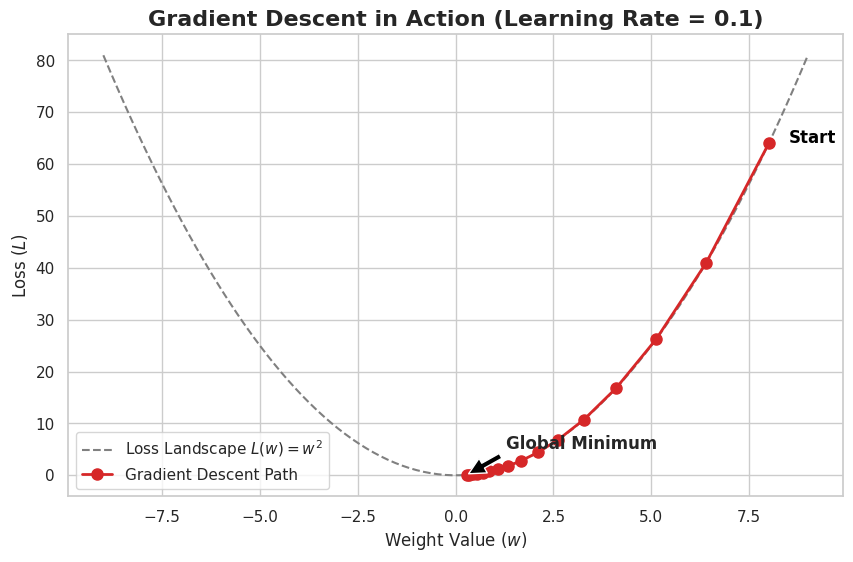

In [2]:
# 1. Define the Math
def calculate_loss(w):
    """The Loss Landscape: A simple parabola (w^2)"""
    return w**2

def calculate_gradient(w):
    """The Calculus: The derivative of w^2 is 2w"""
    return 2 * w

# 2. Initialize Hyperparameters
w_current = 8.0     # Starting random weight
learning_rate = 0.1 # Alpha
epochs = 15         # How many steps to take

# Arrays to store history for visualization
w_history = [w_current]
loss_history = [calculate_loss(w_current)]

print("--- Executing Gradient Descent ---")
print(f"Step 0: Weight = {w_current:.4f} | Loss = {loss_history[0]:.4f}")

# 3. The Optimization Loop
for epoch in range(1, epochs + 1):
    # Step A: Feel the slope (Calculate Gradient)
    gradient = calculate_gradient(w_current)
    
    # Step B: Take a step downhill (The Update Rule!)
    w_current = w_current - (learning_rate * gradient)
    
    # Step C: Record the new position and altitude
    current_loss = calculate_loss(w_current)
    w_history.append(w_current)
    loss_history.append(current_loss)
    
    if epoch % 3 == 0: # Print every 3rd step
        print(f"Step {epoch}: Weight = {w_current:.4f} | Loss = {current_loss:.4f}")

print("✅ Optimization Complete. Reached the bottom of the valley.")

# 4. Matplotlib Visualization of the Journey
plt.figure(figsize=(10, 6))

# Plot the entire mountain (The continuous Parabola)
w_space = np.linspace(-9, 9, 100)
loss_space = w_space**2
plt.plot(w_space, loss_space, color='gray', linestyle='--', label='Loss Landscape $L(w) = w^2$')

# Plot the path of our optimizer
plt.plot(w_history, loss_history, color='#d62728', marker='o', markersize=8, linewidth=2, label='Gradient Descent Path')

# Annotate the start and end points
plt.annotate('Start', xy=(w_history[0], loss_history[0]), xytext=(w_history[0]+0.5, loss_history[0]), 
             fontsize=12, fontweight='bold', color='black')
plt.annotate('Global Minimum', xy=(w_history[-1], loss_history[-1]), xytext=(w_history[-1]+1, loss_history[-1]+5), 
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')

plt.title(f"Gradient Descent in Action (Learning Rate = {learning_rate})", fontsize=16, fontweight='bold')
plt.xlabel("Weight Value ($w$)")
plt.ylabel("Loss ($L$)")
plt.legend()
plt.show()


*(Insight: Look at the visual. The red dots represent the weight updates. Notice how the dots are far apart at the beginning, but get much closer together near the bottom. Because the gradient (the slope $2w$) is physically steeper at $w=8$ than it is at $w=2$, the mathematical step size naturally shrinks as the network approaches the flat bottom of the valley, preventing it from violently overshooting!)*

## Real-World Use Case or Analogy:

Think of Gradient Descent like **A Blindfolded Skier Trying to Reach a Lodge at the Bottom of a Mountain**:

* **The Loss Function**: The actual topography of the mountain. High altitude = High Loss. The lodge at the bottom = Zero Loss.
* **The Starting Weights**: The helicopter drops the skier at a completely random location on the mountain.
* **The Gradient**: The skier cannot see the lodge. They only have the physical sensation of gravity pulling their skis. By feeling which way gravity is pulling hardest (the slope/gradient), they instantly know which direction is "down."
* **The Learning Rate**: The size of the skier's turns. If they point their skis straight down and never turn (massive learning rate), they will hit a ramp, fly over the lodge, and crash into the opposite peak. If they inch forward taking millimeter-sized steps (tiny learning rate), they will freeze to death before reaching the lodge.
* **The Update Rule**: Feel gravity. Take a perfectly sized, controlled turn downhill. Stop. Repeat until the ground is completely flat.